# ISOMAP for Limit Order Books

**Goal.** The 10-level order book produces a 10-dimensional feature vector every minute. This notebook asks whether all 10 dimensions are necessary, or whether two coordinates capture the essential structure — and what those coordinates mean economically.

**Data.** Databento mbp-10 snapshots for NVDA, AAPL, MSFT — full October 2023 (22 trading days). After 1-minute aggregation the working matrix has roughly 8,580 bars per symbol.

**Feature.** 1-minute Order Book Imbalance at each depth level $k$:

$$\text{OBI}_k = \frac{B_k - A_k}{B_k + A_k} \in [-1,\,1]$$

$k = 0$ is the top of book; $k = 9$ is the deepest level available in the feed.


In [1]:
from IPython.display import Image, display

---
## 1. The Raw Data

Each row in the dataset is a full 10-level order book snapshot — one snapshot is generated every time any order is placed, modified, or cancelled. The raw files contain tens of millions of event-level updates over the full October sample; after 1-minute aggregation the working matrix has roughly 8,580 bars per symbol.

The snapshot below is taken just after the open (09:30 ET). Bid sizes are positive, ask sizes are negative.


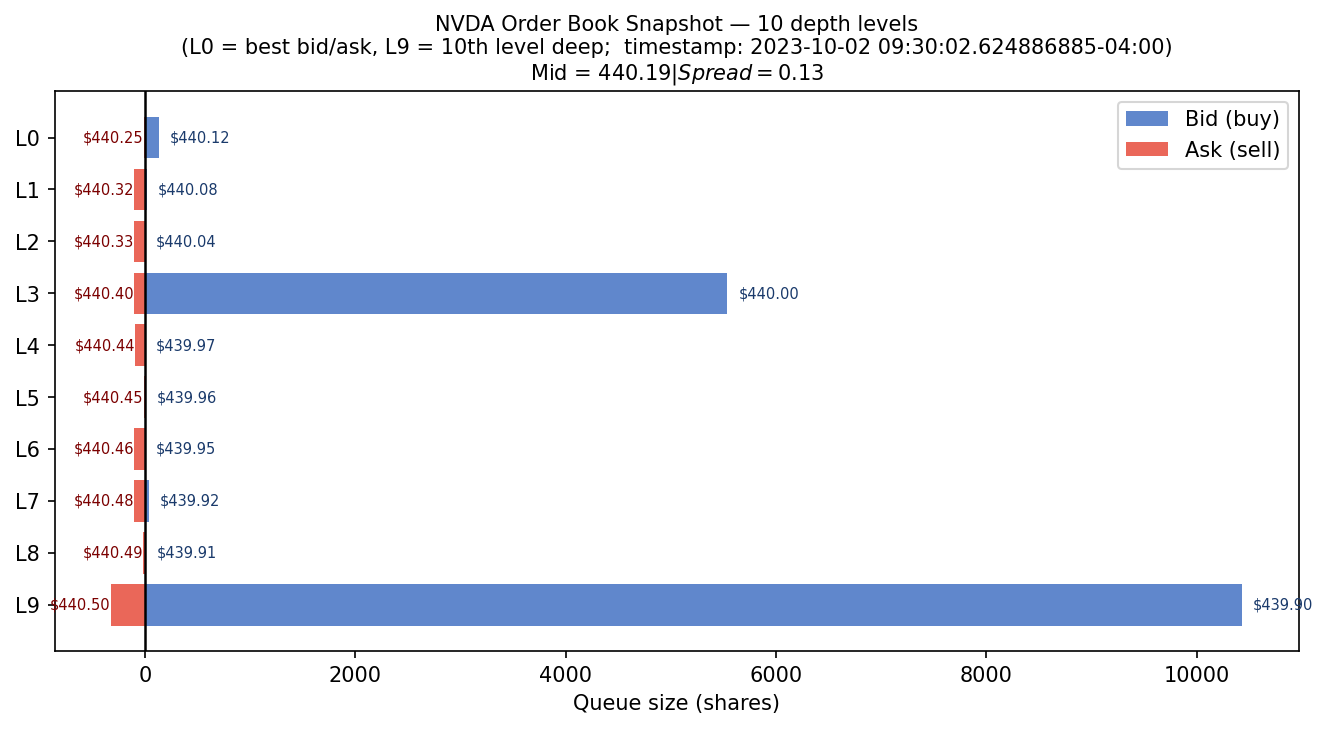

In [2]:
display(Image('figures/4f_ob_snapshot.png'))

A single event-level snapshot can be noisy and uneven — resting sizes vary considerably across levels and the book is rarely perfectly symmetric at any given moment. That is why we aggregate into 1-minute OBI profiles before doing any analysis: averaging over potentially thousands of updates within a minute gives a stable summary of the book's directional lean.

### From tick-level snapshots to 1-minute bars

Taking the mean OBI within each minute gives a matrix of shape (minutes × 10). The figure below shows the full 1-minute OBI time series for one trading day across all 10 depth levels.


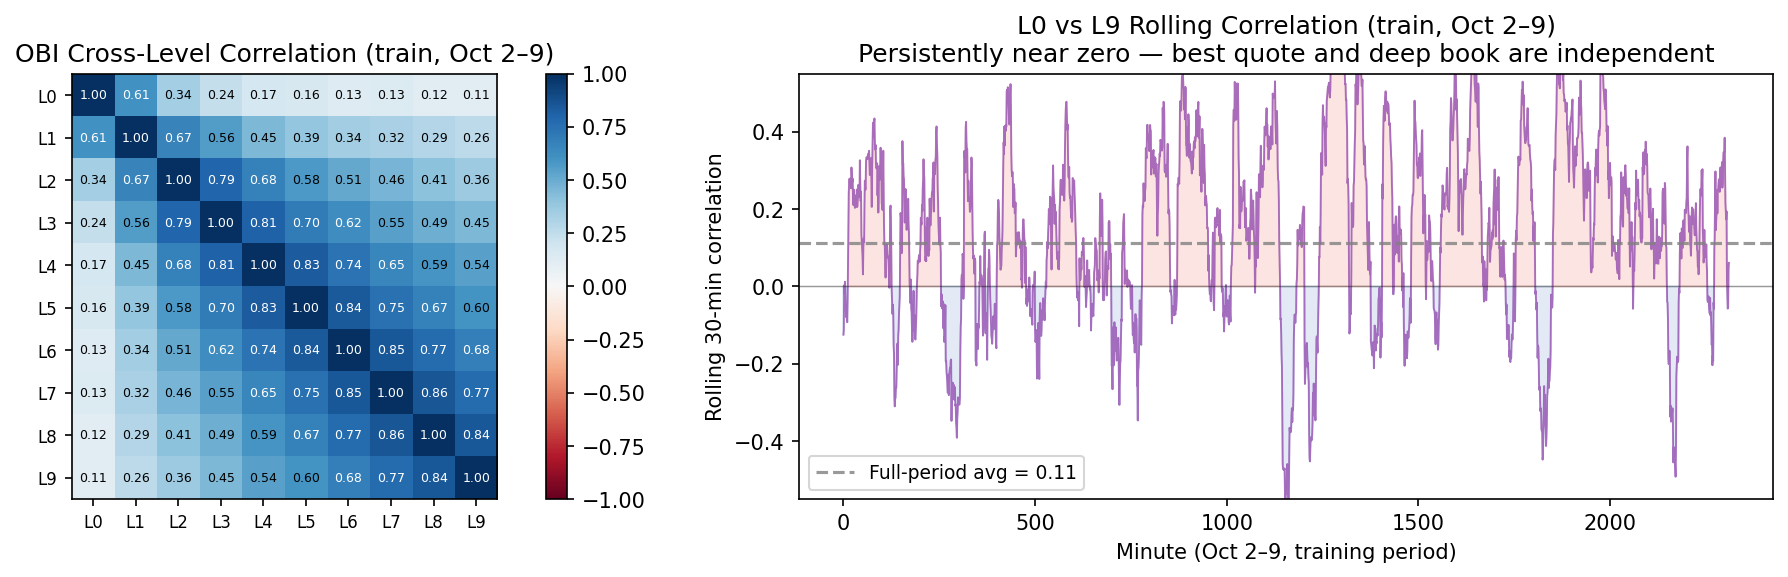

In [3]:
display(Image('figures/4f_obi_structure.png'))

---
## 2. Why Should the Book State Be Low-Dimensional?

The 10 OBI levels are not independent. Adjacent levels tend to move together — if the bid is heavy at L2, it is usually heavy at L3 too. The cross-level correlation matrix makes this concrete:


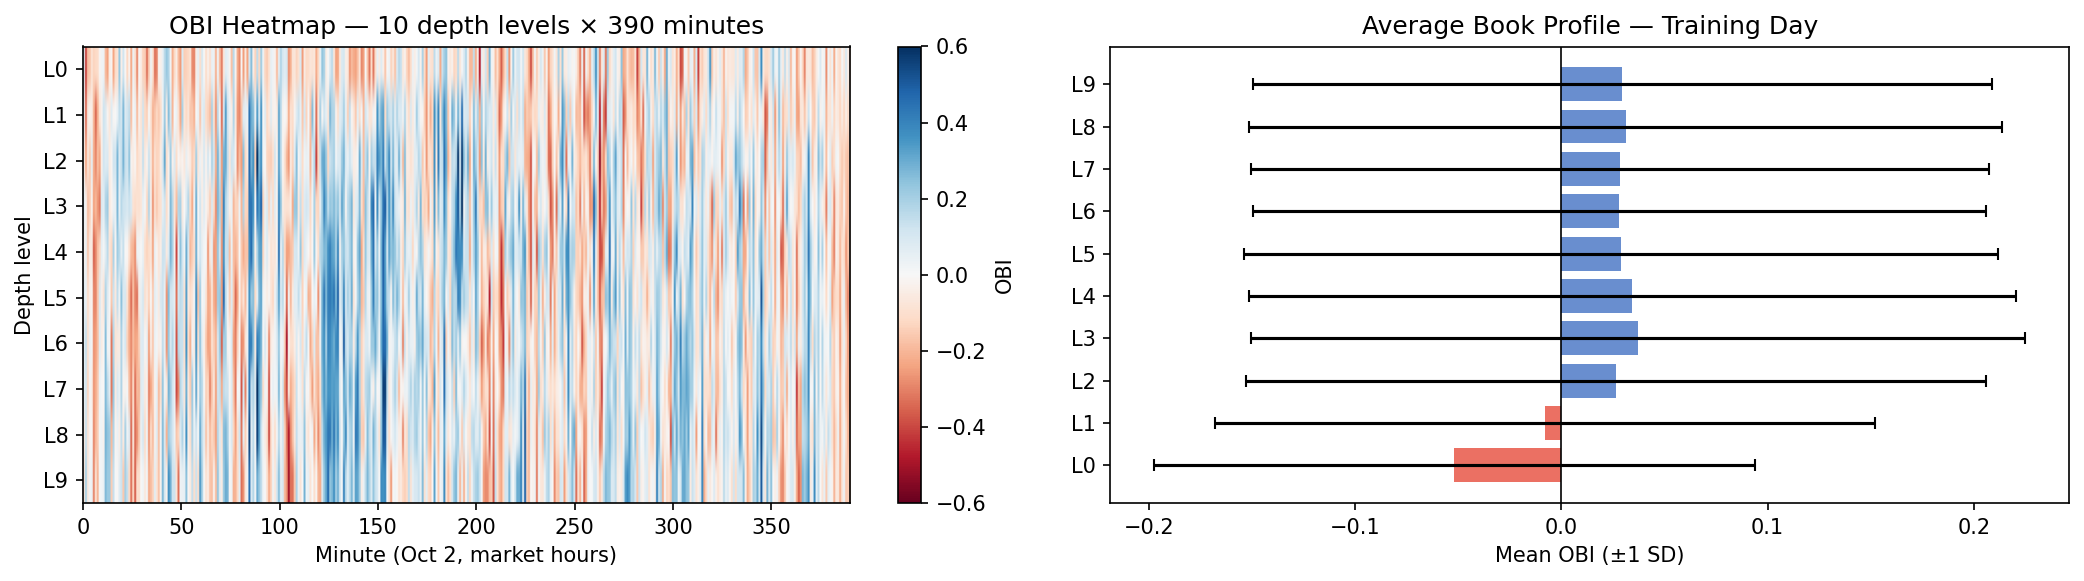

In [4]:
display(Image('figures/4f_obi_heatmap.png'))

Nearby levels are correlated — L0 and L1 share a Spearman ρ of about 0.61, rising to 0.86 for L7–L8. The far ends of the book (L0 vs L9) are nearly uncorrelated at 0.11. The book does not fill all 10 dimensions independently — it lives near a lower-dimensional surface inside that space. That surface is what we want to find.


---
## 3. ISOMAP — A Three-Step Pipeline

ISOMAP recovers the low-dimensional manifold that the data lies near. It has three steps.

**Step 1 — k-NN graph.** Connect each 1-minute bar to its $k$ nearest neighbors in the 10D OBI space. Two bars are neighbors if their full book profiles are similar at all levels. The single-symbol figures in this notebook use $k = 15$; the pooled joint model and stress projection use $k = 30$ because the denser dataset supports a larger neighborhood.

**Step 2 — Geodesic distances.** For bars that are not direct neighbors, compute the shortest path through the graph (Dijkstra's algorithm). This is the *geodesic* distance — measured along the manifold surface rather than through empty space. If the manifold curves, the straight-line Euclidean distance cuts through regions no real bar occupies; the geodesic respects the shape.

**Step 3 — MDS embedding.** Find a 2D layout $(Z_1, Z_2)$ whose Euclidean distances match the geodesic distances as closely as possible. This is multidimensional scaling applied to the geodesic distance matrix.

In code, the full pipeline is five lines:


```python
from sklearn.manifold import Isomap

isomap = Isomap(n_neighbors=15, n_components=2)
Z_train = isomap.fit_transform(X_train)   # X_train: (n_bars, 10) OBI matrix
Z_oos   = isomap.transform(X_oos)         # Nyström extension for held-out bars
print(f"Reconstruction error: {isomap.reconstruction_error():.4f}")
```


---
## 4. Does Two Dimensions Capture Enough?

The ISOMAP reconstruction error measures how much of the manifold's geodesic structure is lost in the 2D projection:

$$\text{Reconstruction error} = \frac{\operatorname{Var}(d_{\text{geo}} - d_{\text{embed}})}{\operatorname{Var}(d_{\text{geo}})}$$

Zero is a perfect embedding; one means the embedding is no better than predicting the mean distance. Note that this is a *geometry-fidelity* measure specific to ISOMAP — it is not directly comparable to PCA explained variance, which is defined over Euclidean distances. The scree plot below reports $(1 - \text{residual})$ for ISOMAP alongside $(1 - \text{residual})$ for PCA, where PCA's residual is computed the same way for comparability.


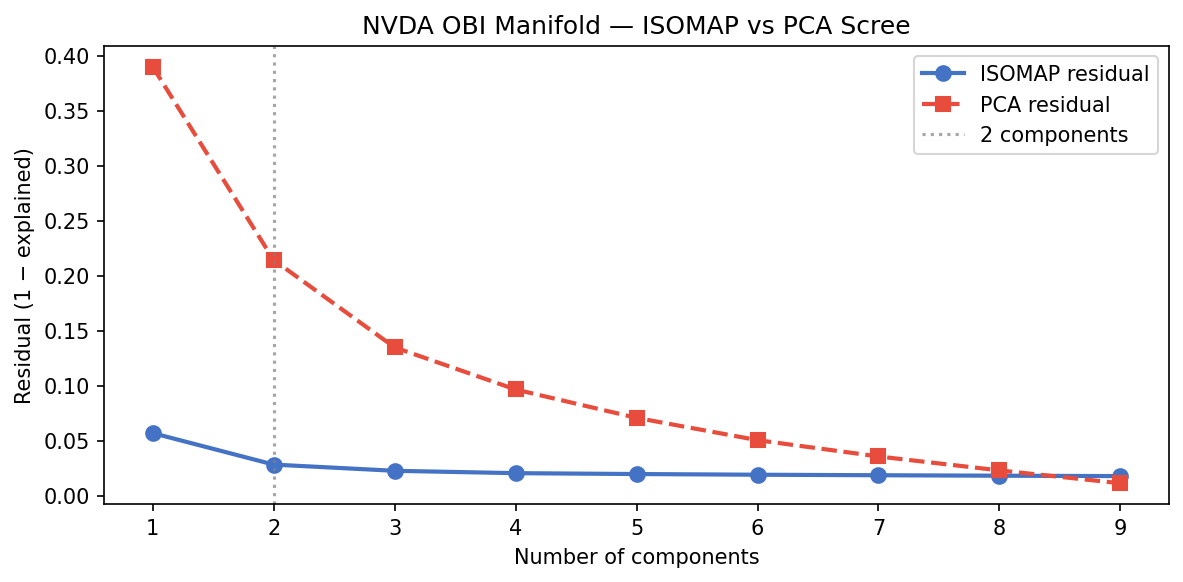

In [5]:
display(Image('figures/4g_NVDA_scree.png'))

The scree curve has a clear elbow at two components for ISOMAP. Adding a third component reduces the residual by less than one percentage point. PCA needs more components to reach the same residual level, because it cannot follow the curvature of the manifold. The ISOMAP advantage is largest for NVDA.

| | NVDA | AAPL | MSFT | Joint (pooled) |
|---|---|---|---|---|
| ISOMAP 2D (1 − residual) | 97.2% | 96.7% | 96.7% | 97.3% |
| PCA 2D (1 − residual) | 78.6% | 82.2% | 87.0% | 81.9% |
| Gap | +18.6 pp | +14.5 pp | +9.7 pp | +15.4 pp |

The gap is consistent across all four fits. It comes from curvature in the book state manifold — a structure that a flat PCA projection cannot capture.


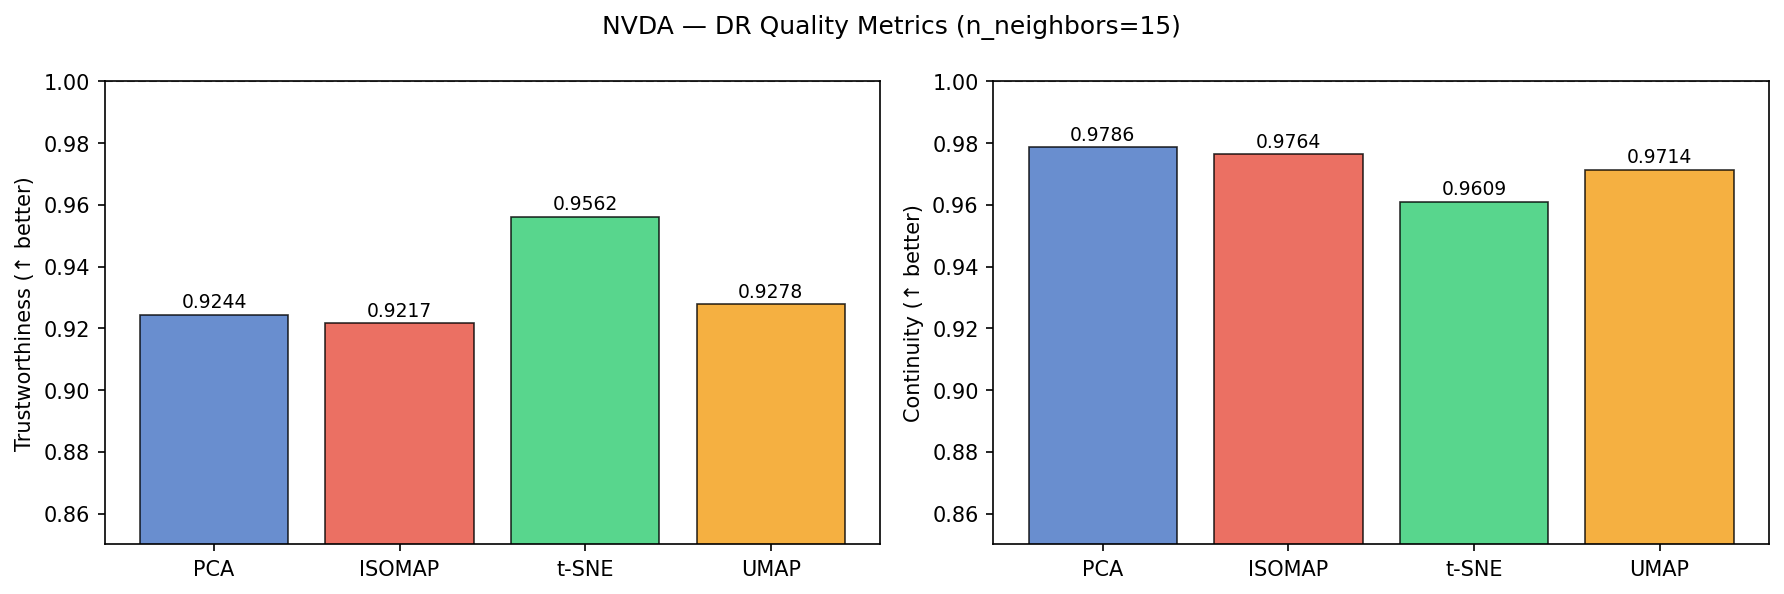

In [6]:
display(Image('figures/4g_NVDA_dr_quality.png'))

Trustworthiness and Continuity measure whether the embedding preserves local neighborhood structure (independent of the geodesic criterion). Both metrics exceed 0.97 for ISOMAP across all three stocks, confirming that the 2D embedding is not distorting local structure while optimising global distances.

### Sensitivity to the choice of k

ISOMAP requires choosing a number of neighbors $k$. The result should not depend sensitively on this choice — if it did, the manifold would not be a stable description of the data.


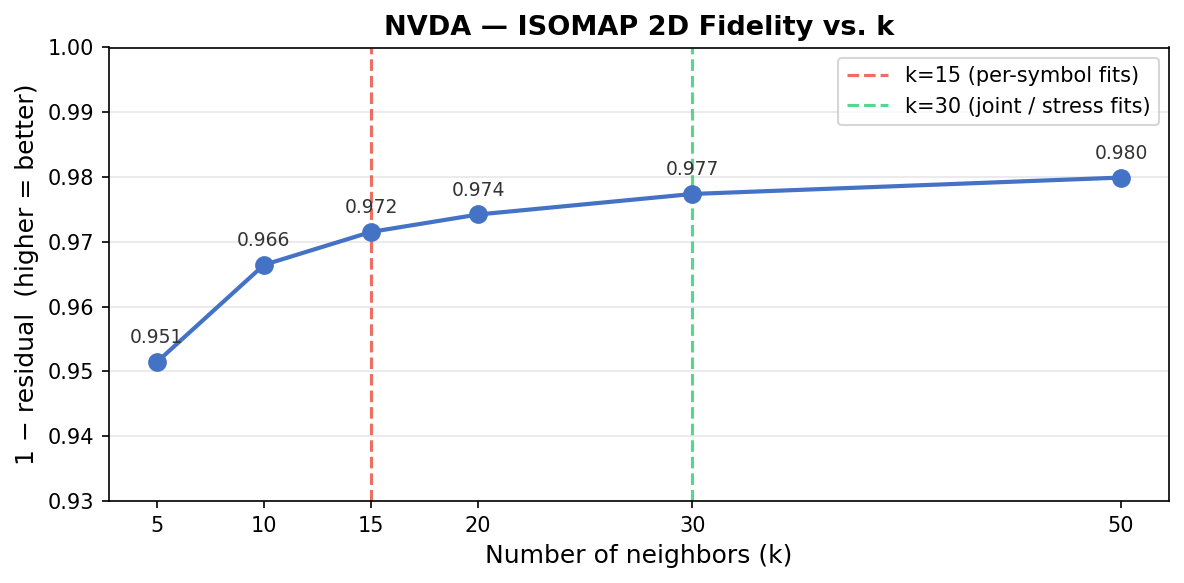

In [7]:
display(Image('figures/4g_NVDA_neighbor_sensitivity.png'))

The 2D fidelity is stable from k=5 through k=50: the residual decreases monotonically from 0.049 to 0.020 as k grows (more neighbors → smoother geodesic graph → lower residual), but the qualitative result — a strong 2D elbow — holds at every value tested. The per-symbol figures use k=15; the joint model and stress projection use k=30. Neither choice is fragile.


---
## 5. What Do Z₁ and Z₂ Capture?

The 2D ISOMAP output assigns each 1-minute bar a pair of coordinates $(Z_1, Z_2)$. ISOMAP has no knowledge of time, returns, or which stock the bar came from. The coloring below is added after the fact.


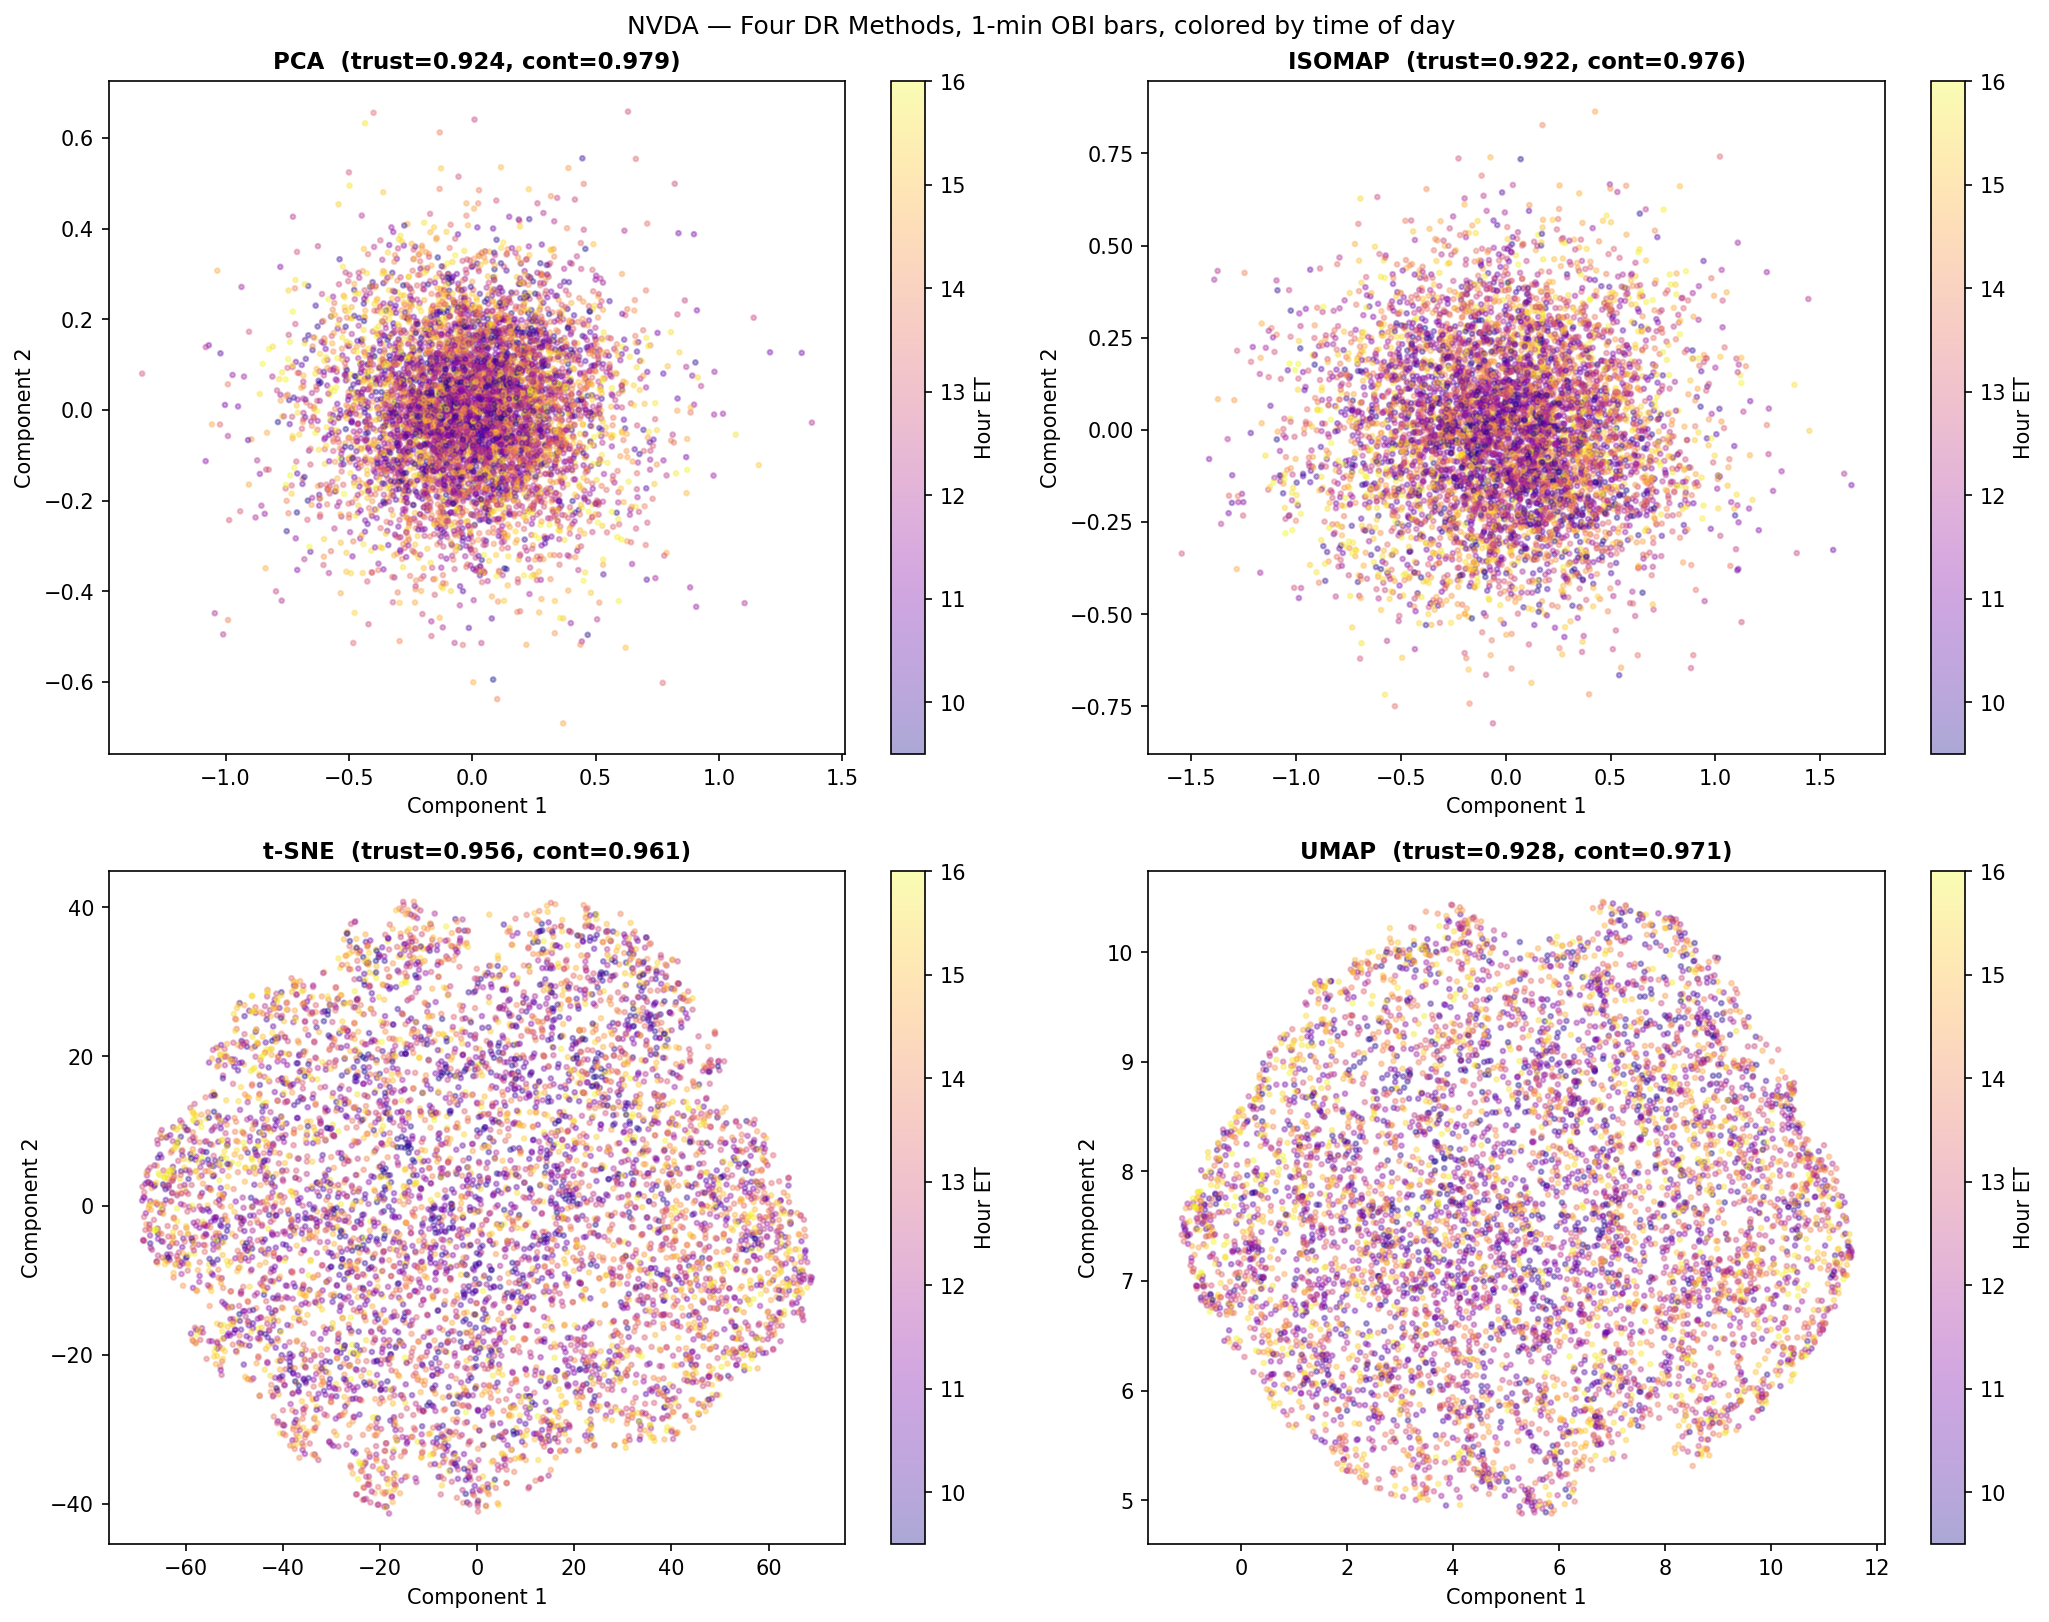

In [8]:
display(Image('figures/4g_NVDA_dr_tod.png'))

The ISOMAP panel (top-left) shows that open and close bars tend to occupy a different part of the learned space from mid-day bars, though the separation is partial and not categorical — the book revisits similar states at different times. This structure was not given to the model; it comes from the geometry of the observed OBI profiles.

To give the axes an economic label, compute the Spearman correlation between each ISOMAP coordinate and the raw OBI at each of the 10 depth levels:


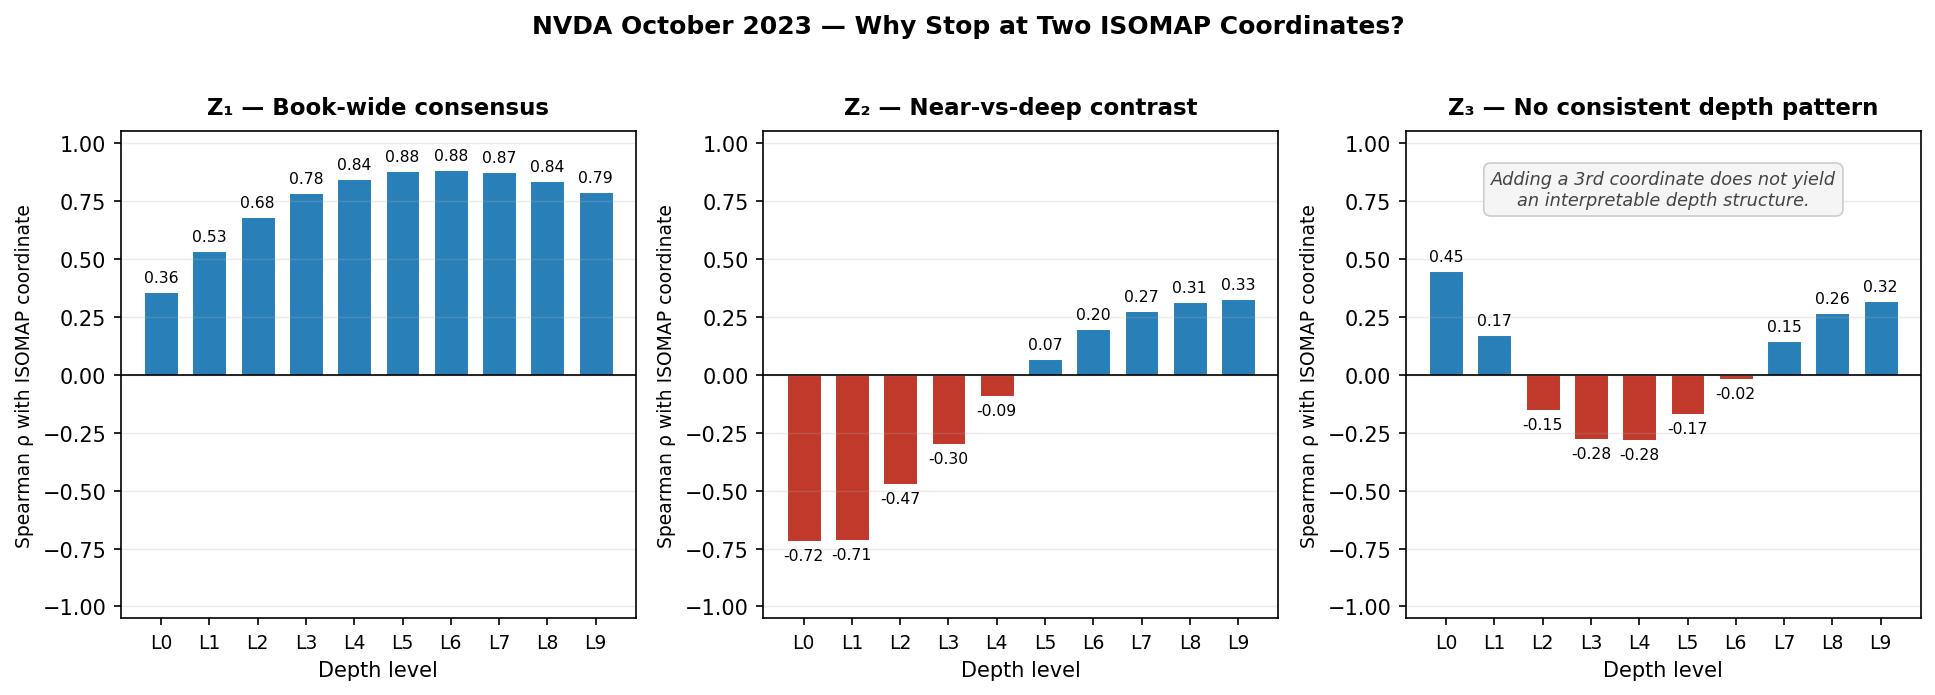

In [9]:
display(Image('figures/4g_NVDA_depth_profile_full.png'))

**Z₁** has the same sign across all 10 levels and peaks at L6 (ρ = 0.88 in the full-October fit). Every depth level contributes to Z₁ in the same direction — it measures how bullish or bearish the *entire* book stack is. A high-Z₁ minute means the book is bid-heavy from top to bottom; a low-Z₁ minute means it is ask-heavy from top to bottom.

**Z₂** is negative near the top of book (L0 ρ = −0.72) and crosses zero between L4 and L5, becoming positive in the deep book (L9 ρ = +0.33). It captures the contrast between the near-book and the deep book — parts of the order book that often lean in opposite directions. The sign of Z₂ is arbitrary (ISOMAP can flip an axis without changing geometry); what is stable is the *crossing pattern* around L4–L5.

**Why not Z₃?** The third component (right panel) has a maximum |ρ| of 0.45 and no consistent pattern across depth — positive near L0, turning negative mid-book, positive again at L9. There is no clean economic label for this shape. Both the scree elbow (< 1 pp gain from a third component) and the uninterpretable depth profile point to the same conclusion: two coordinates are enough.

The figure below makes the axis interpretation concrete by showing the average OBI profile for bars at the extremes of each coordinate:


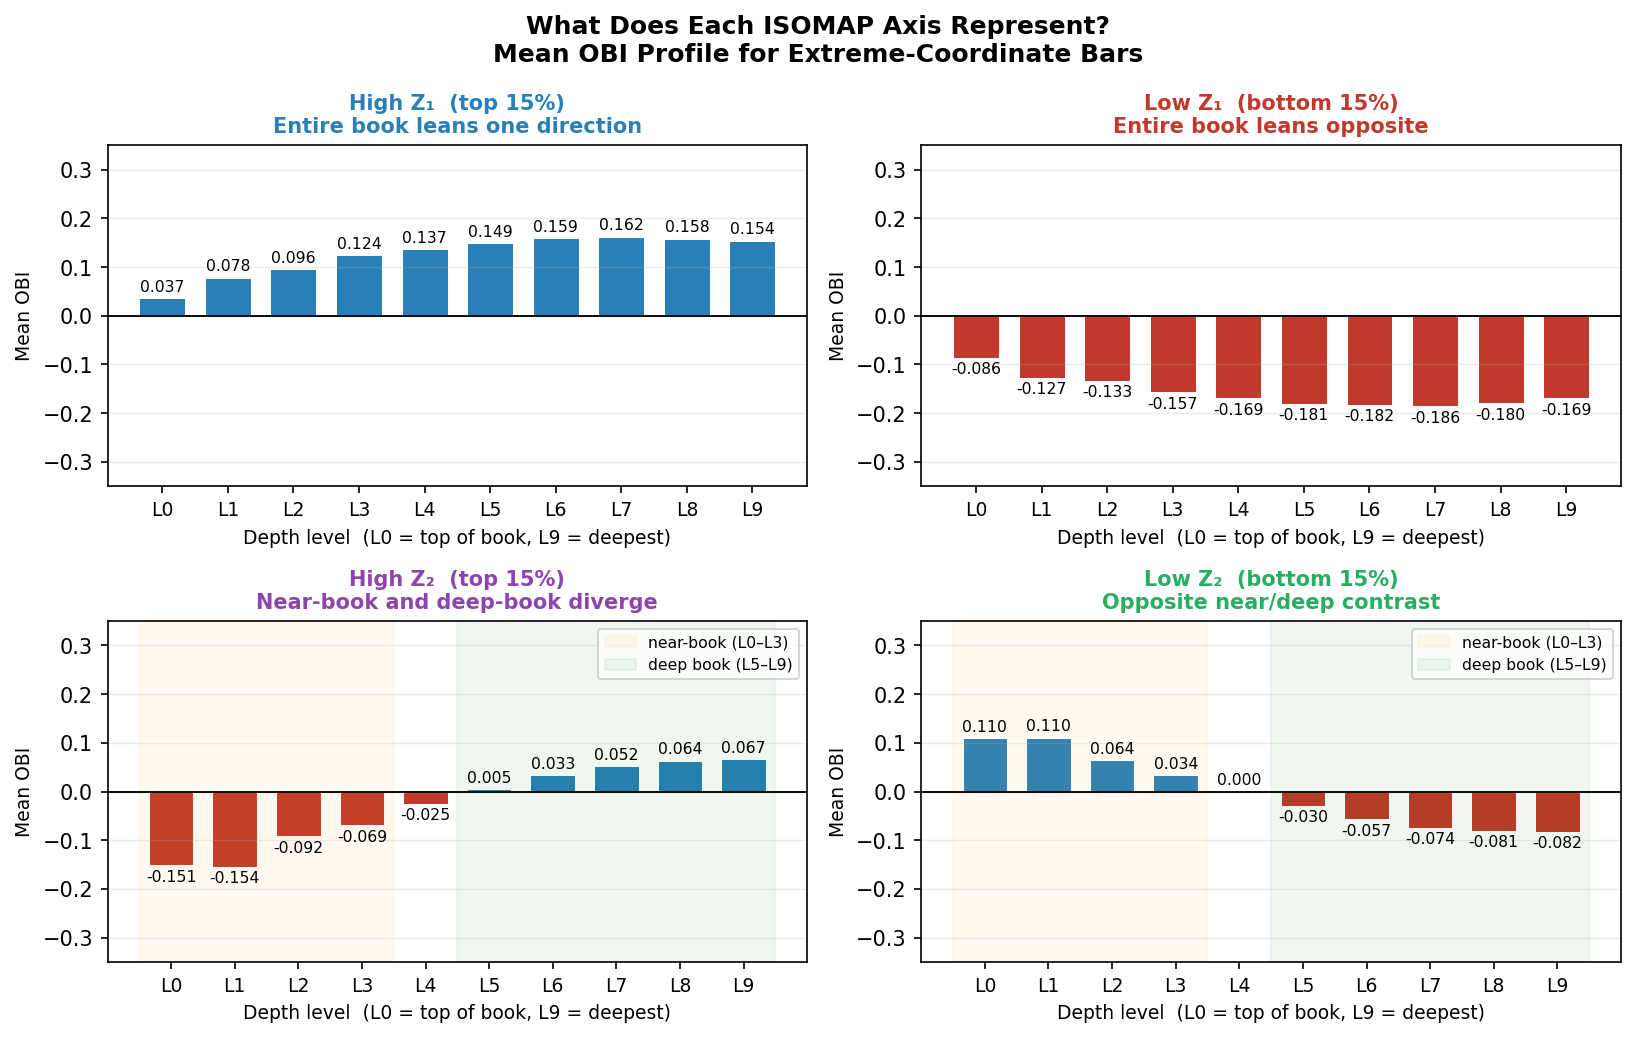

In [10]:
display(Image('figures/4g_NVDA_axis_profiles.png'))

**Top row — Z₁ extremes:** High-Z₁ bars (top 15%) have OBI ranging from +0.04 at L0 to +0.16 at L6 — the entire book leans bid-side, with the largest imbalance in the mid-book where market makers post the most resting size. Low-Z₁ bars are the mirror image (−0.09 to −0.19), with the whole stack leaning ask-side.

**Bottom row — Z₂ extremes:** High-Z₂ bars show near-book OBI of −0.12 (ask-heavy at L0–L3) while the deep book is +0.04 (mildly bid-heavy at L5–L9). Low-Z₂ bars reverse this: near-book +0.08, deep book −0.07. The two halves of the book are pulling in opposite directions.

These patterns emerge purely from the geometry of the data — ISOMAP was not told about depth levels, bid/ask directions, or economic intuition.


---
## 6. Out-of-Sample Generalization

The ISOMAP is trained on the first 75% of October. The remaining 25% is held out and projected using the Nyström extension (`isomap.transform()`). A well-learned manifold should accommodate OOS bars inside the region covered by the training set.


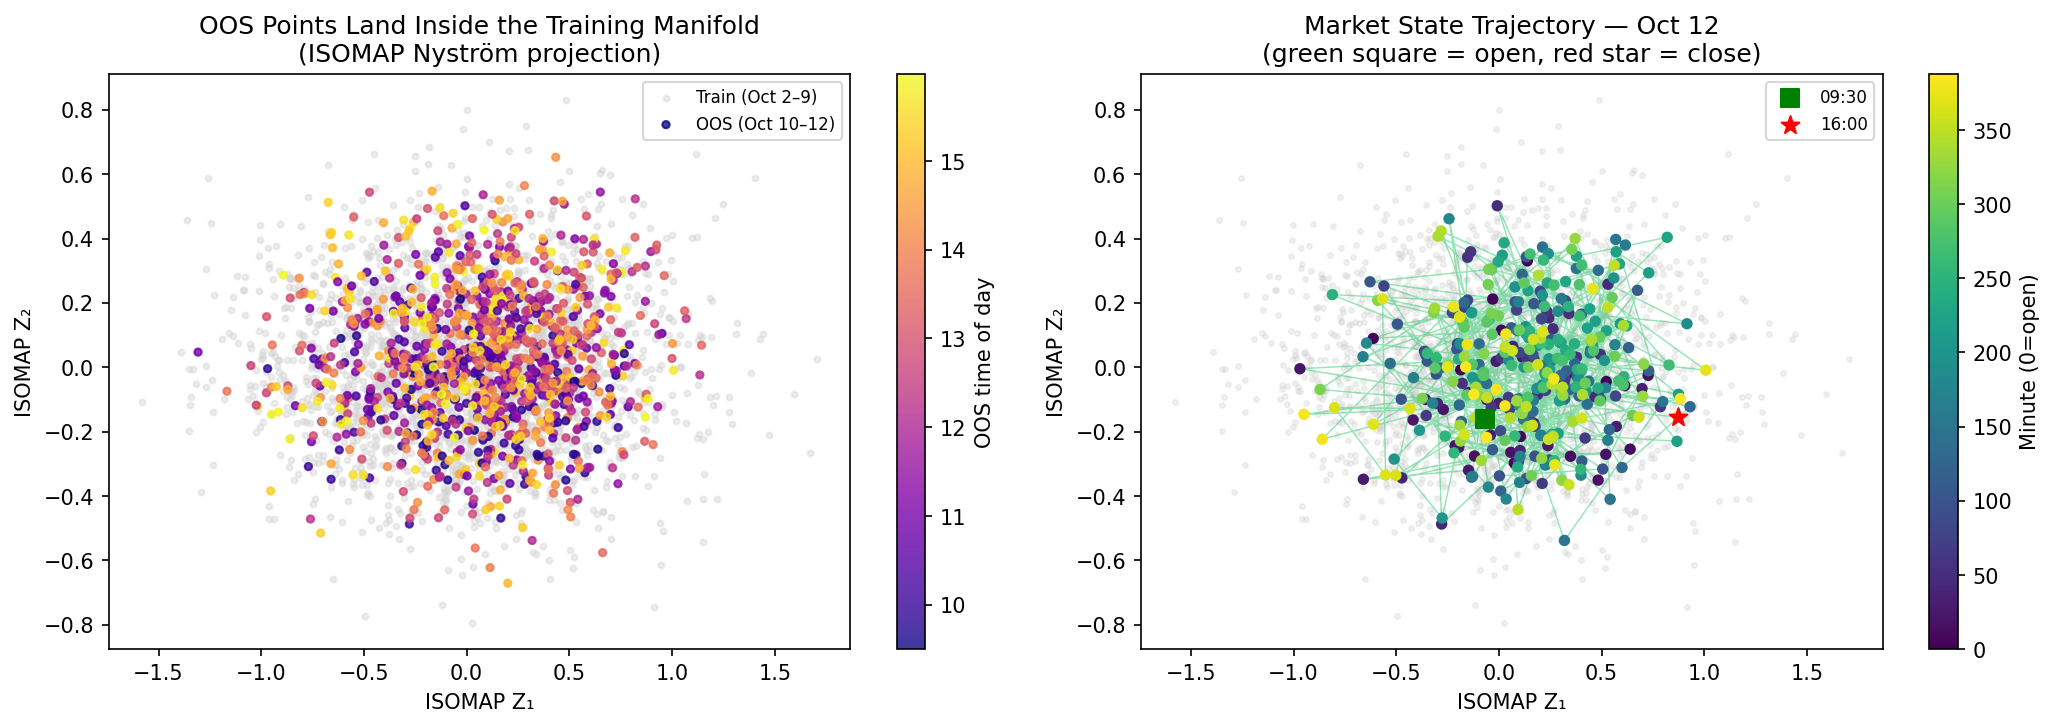

In [11]:
display(Image('figures/4f_oos_projection.png'))

OOS bars land inside the region covered by the training set. The learned manifold structure is stable over the hold-out period.

Does the 2D representation contain any short-horizon return signal?


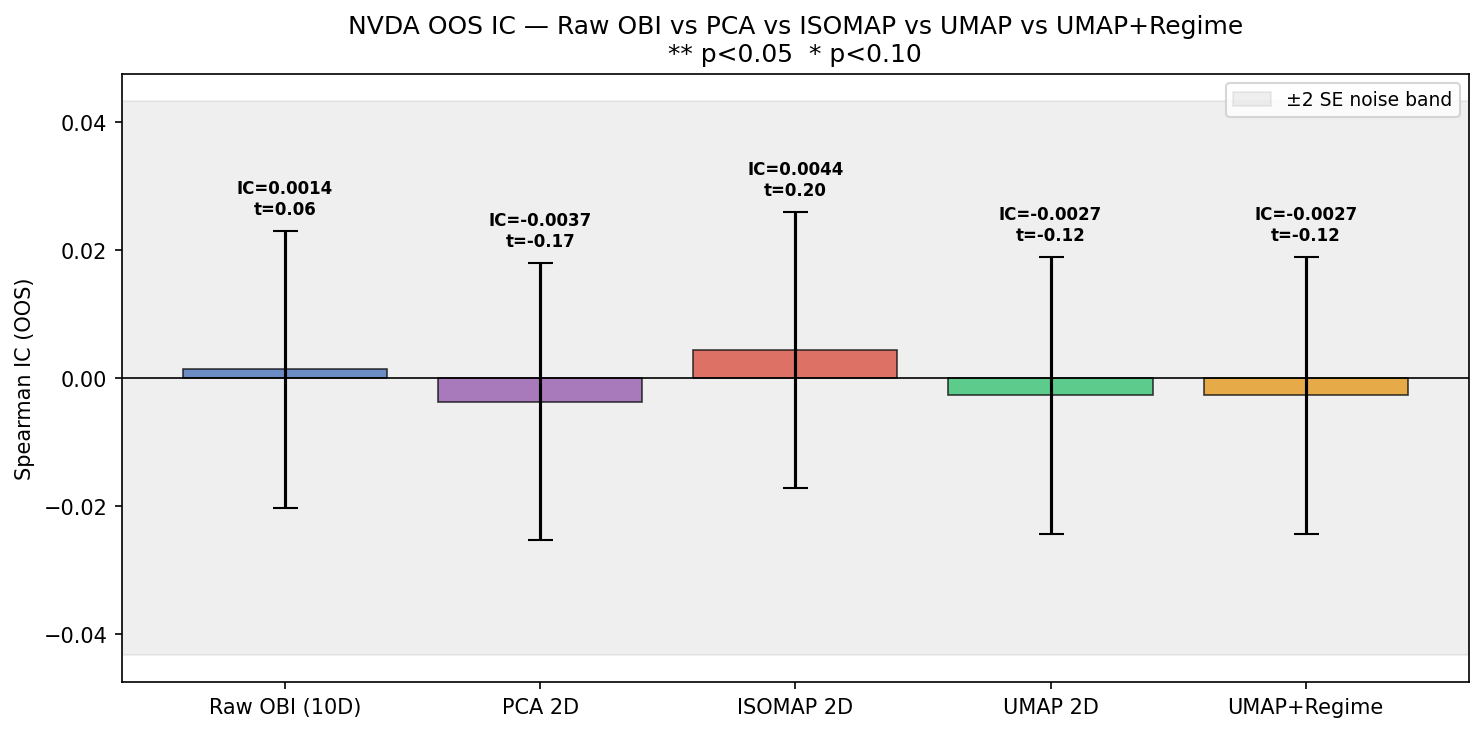

In [12]:
display(Image('figures/4g_NVDA_oos_ic.png'))

The ISOMAP 2D IC is slightly positive for NVDA in this sample, and larger than the raw OBI IC (which tends to cancel across levels). The p-value is around 0.20 — not statistically strong. The main value of the representation is not standalone return prediction; it is a compact, interpretable description of book state that can be used as input to downstream models or as a baseline for stress detection.


---
## 7. Does the Same Structure Appear in Other Stocks?

The analysis above used NVDA. Fitting the same pipeline independently on AAPL and MSFT, and then fitting one joint model on all three pooled together, gives the following picture.

| | NVDA | AAPL | MSFT | Joint (pooled) |
|---|---|---|---|---|
| ISOMAP 2D (1 − residual) | 97.2% | 96.7% | 96.7% | 97.3% |
| Z₁ peak level | L6 | L7 | L4 | L5 |
| Z₂ sign-flip around | L4–L5 | L5–L6 | L4 | L5 |
| Best K (UMAP) | 2 | 2 | 2 | 2 |

The exact depth level where Z₁ peaks and Z₂ crosses zero shifts slightly — MSFT's book is more concentrated near the top. But the qualitative pattern (Z₁ = consensus, Z₂ = near-vs-deep contrast, K=2 regimes) replicates across all three stocks independently.

The joint embedding below fits one ISOMAP on the ~26,000-bar pooled matrix:


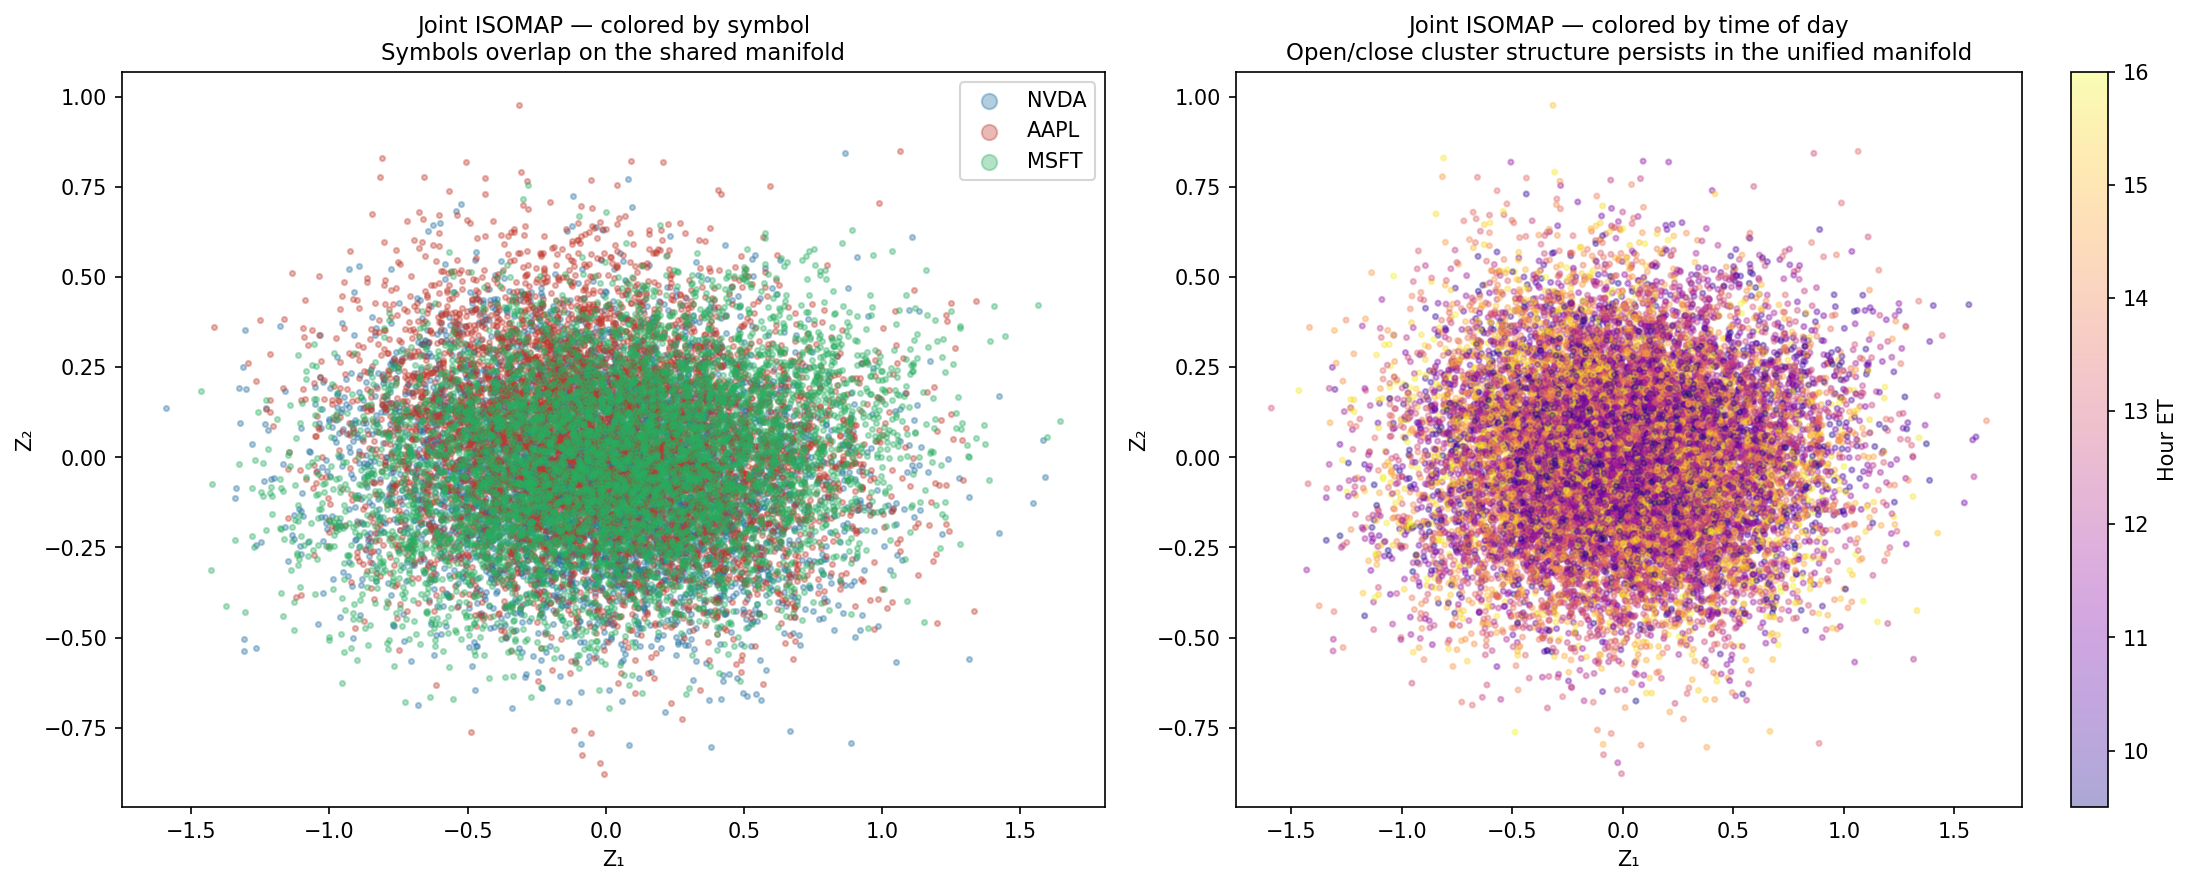

In [13]:
display(Image('figures/4h_joint_embedding.png'))

**Left — by symbol:** NVDA, AAPL, and MSFT points substantially overlap on the shared manifold. There is no clean region that belongs to one stock only. The book geometry is driven by market-wide structure rather than stock-specific signals.

**Right — by time of day:** Time-of-day patterns are visible, especially near the open and close, but the joint embedding is best interpreted as a shared book-state space rather than a pure time-of-day map — many states are visited at multiple times of day.


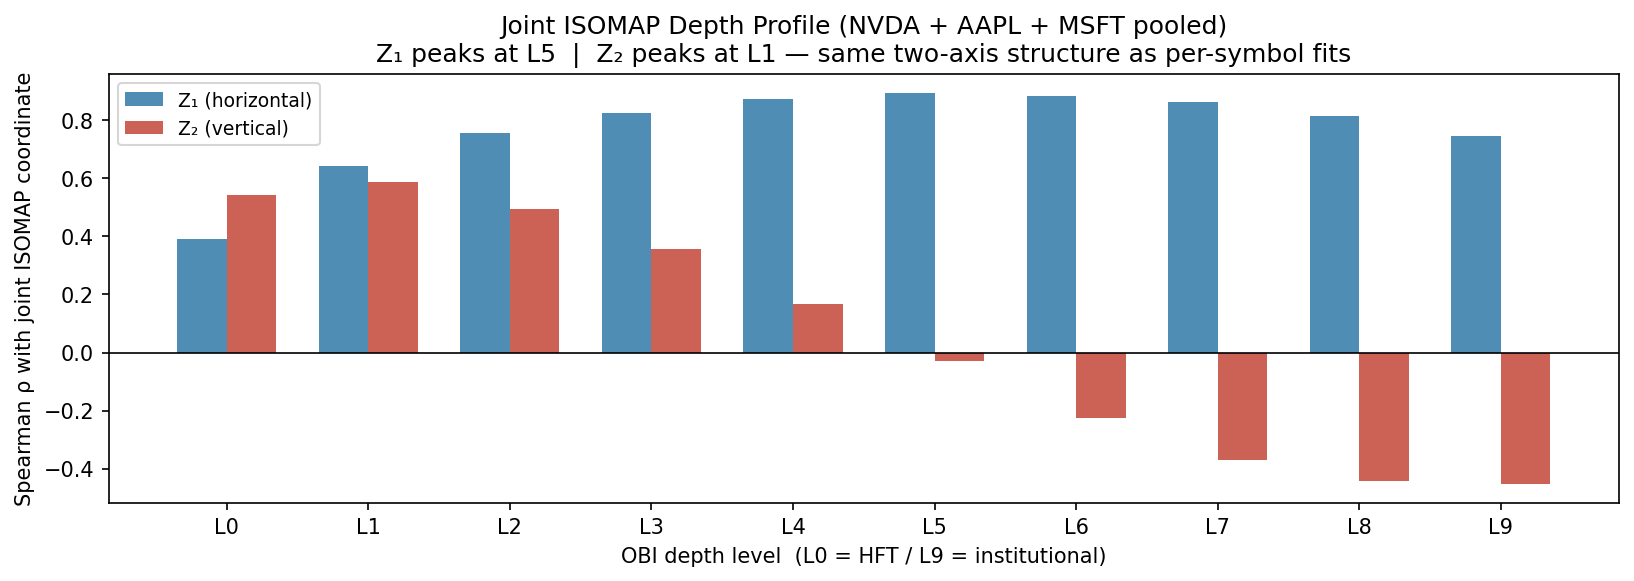

In [14]:
display(Image('figures/4h_joint_depth_profile.png'))

The joint depth profile replicates the per-symbol pattern: Z₁ peaks at L5, Z₂ changes sign around L4–L5. The two-axis interpretation survives pooling across stocks — it is not a per-symbol artifact.


---
## 8. Stress Period Projection: The BOJ Shock Week

The Bank of Japan's July 31, 2024 rate-hike decision, effective August 1, triggered a rapid unwind of yen carry trades. On August 5, global equity markets sold off sharply and volatility spiked: the VIX opened near 65 (highest since March 2020), and NVDA fell from ~$110 to ~$92 intraday (−16%).

The ISOMAP trained on calm October 2023 provides a coordinate system. Projecting the August shock week onto it asks: *do stress-period book states look geometrically unusual?*

Two representations are compared:
- **Model A (OBI means only, 10 features):** the same feature set used throughout this notebook
- **Model B (OBI means + within-minute OBI std, 20 features):** adds a second moment capturing how stable the book was within each 1-minute bar


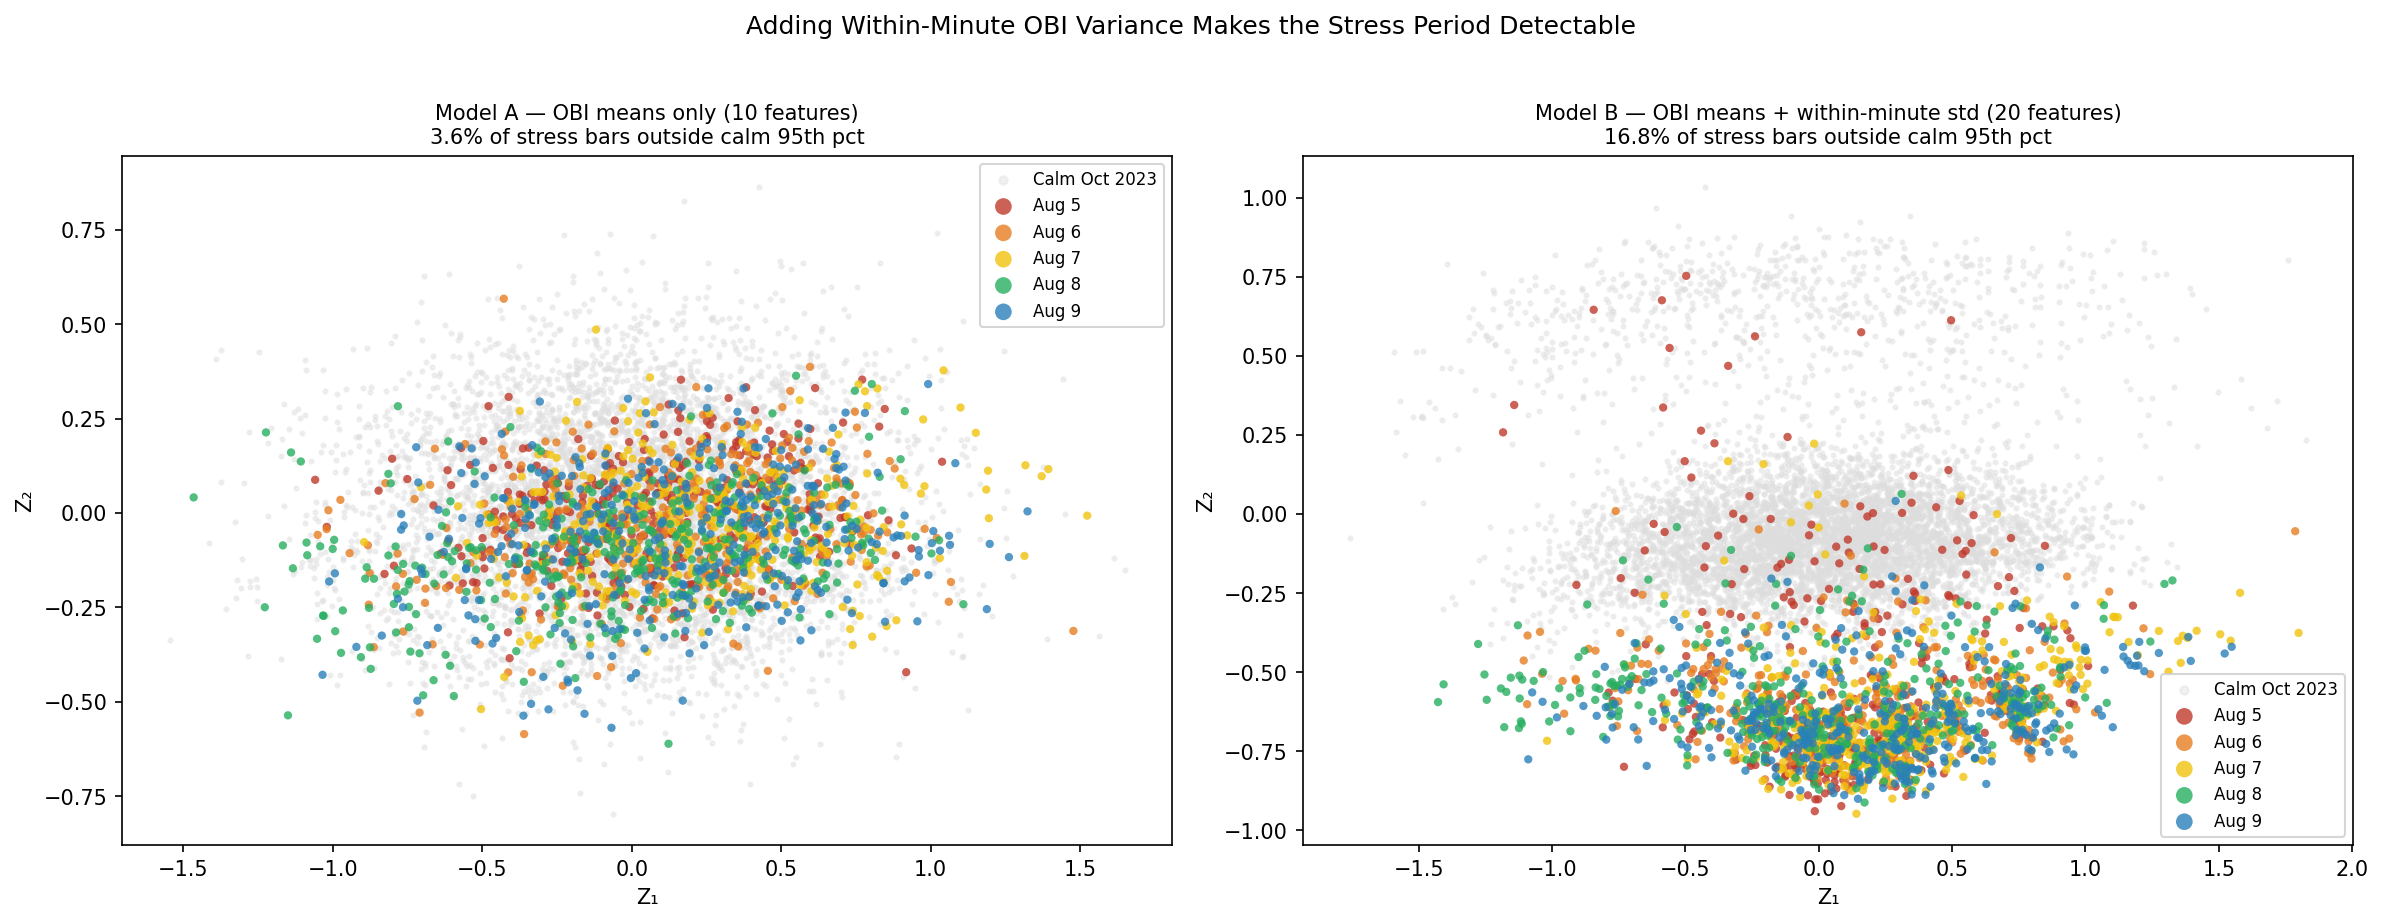

In [15]:
display(Image('figures/4i_model_comparison.png'))

**Model A (left):** Stress bars land almost entirely inside the calm cloud. Only 3.6% fall outside the calm 95th percentile. The 1-minute mean OBI washes out the directional signal: during a directional crash, every update within a minute points the same way, so the mean is moderate and unremarkable.

**Model B (right):** Stress bars shift away from the calm region. 16.8% are outside the calm 95th percentile, and the stress mean distance is **2× the calm mean**. The within-minute OBI standard deviation is lower during the crash (every update aligned → less within-minute variance), and this second-moment difference is what separates stress from calm on the manifold.

| | Model A (means only) | Model B (means + std) |
|---|---|---|
| Features | 10 | 20 |
| Stress bars outside calm 95th | 3.6% | **16.8%** |
| Stress mean distance / Calm mean | 0.91× | **2.04×** |

The stress separation increases through the week — 8.2% on Aug 5 (crash day, most directional) to 25.2% on Aug 9 (recovery, buyers and sellers disagreeing).


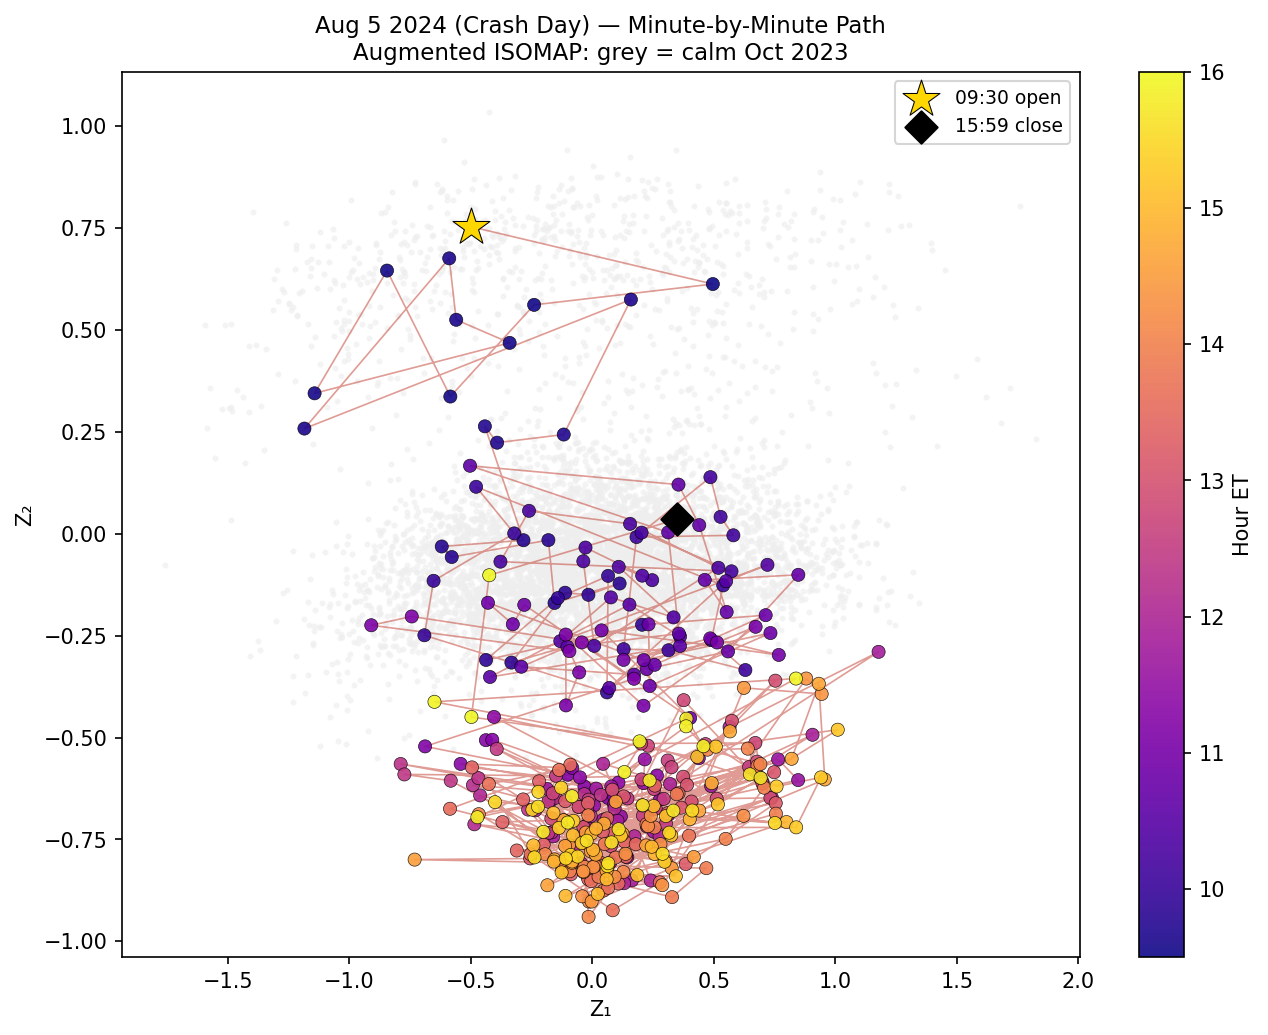

In [16]:
display(Image('figures/4i_aug5_path.png'))

The minute-by-minute trajectory on Aug 5 starts in the upper-left (crash open, gold star) and moves through a sparse region of the manifold. The path is directed and compact — the book does not backtrack much, consistent with sustained one-way selling pressure. By the close (black diamond) the book has drifted to a region that corresponds to calm late-afternoon configurations.


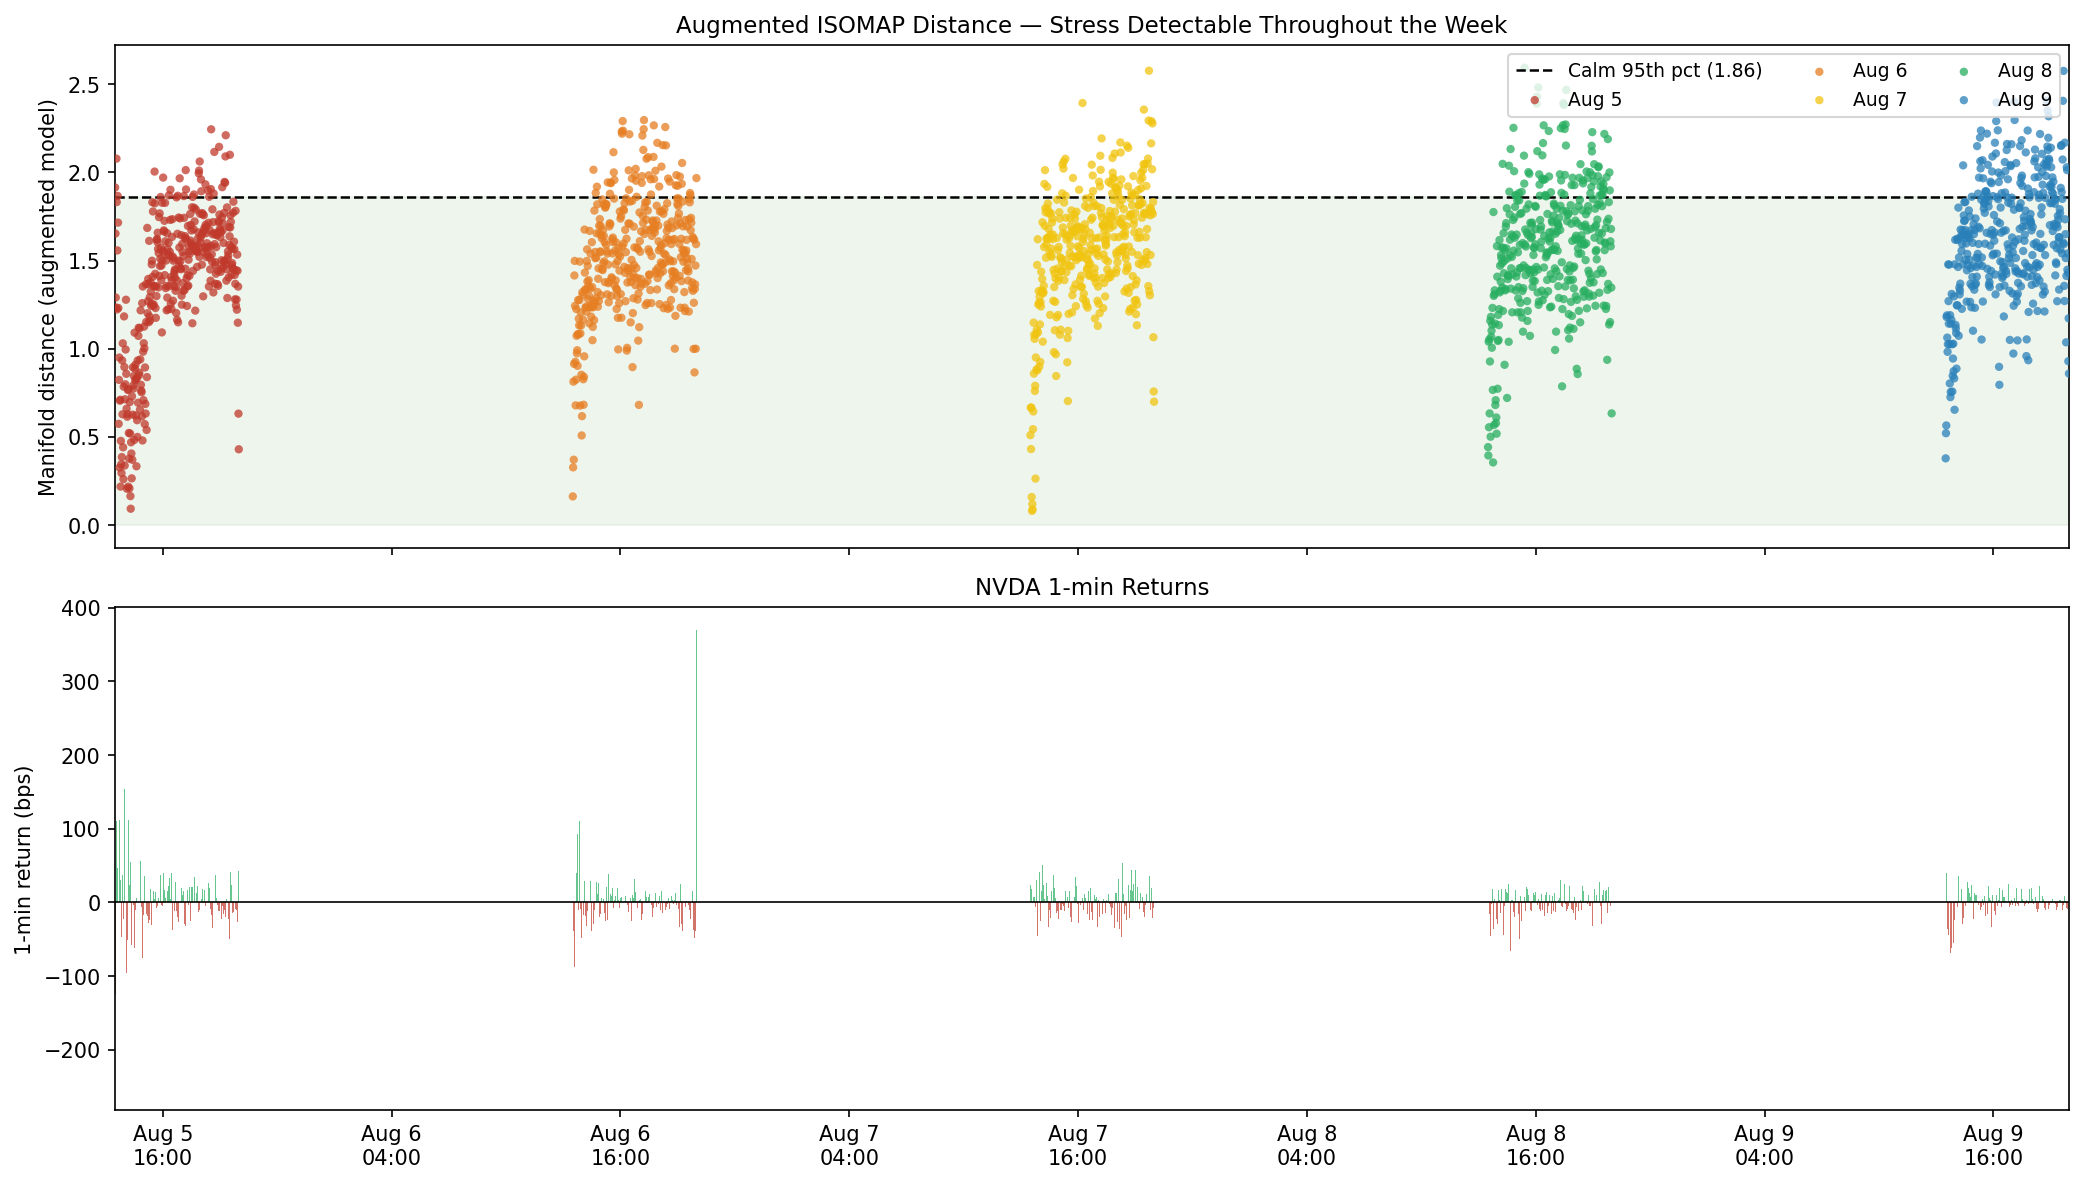

In [17]:
display(Image('figures/4i_manifold_distance.png'))

The stress distance distribution shifts upward throughout the week, with the most extreme spikes concentrated at market open each day — when the book has the most unusual configuration relative to its calm-period counterpart. Not every stress bar exceeds the calm 95th percentile; 16.8% do under Model B, compared to 5% by construction for calm. The elevated tail is the signal.

The return volatility panel (bottom) tells the complementary story: Aug 5 has the highest daily vol but is not the most anomalous day in manifold distance. The structural unusualness of the book peaks during the recovery, when market participants are actively reassessing direction.


---
## Conclusion

The 10-level OBI matrix has a clear 2D structure across NVDA, AAPL, MSFT, and the pooled joint model. ISOMAP's residual drops sharply at two components for all four fits, and the gap over PCA is consistent — reflecting genuine curvature in the book state manifold that a flat projection cannot follow.

The two coordinates have a stable interpretation: Z₁ is a broad book-wide consensus axis; Z₂ captures the contrast between near-book and deep-book imbalance, changing sign around the L4–L5 boundary. The exact sign of Z₂ can flip between fits — that is a known property of ISOMAP — but the crossing pattern and the economic interpretation are consistent across all stocks tested.

The stress projection is the practical test. Mean OBI alone (Model A) does not separate calm from stressed book states — the 1-minute mean is unremarkable even during a directional crash where every update within the minute points the same way. Adding within-minute OBI standard deviation (Model B) reveals a structural difference: a more directional, less-flickering book during stress. 16.8% of stress bars fall outside the calm 95th percentile in manifold distance, compared to 3.6% with means alone.

The main contribution here is a state representation for liquidity-regime detection, not standalone return prediction. The geometry of the order book encodes information about the market's current regime that is not visible in the 1-minute mean OBI alone.
